In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation



In [11]:
odf = pd.read_csv('raw/all_subrs_3000sample.csv')
odf['created_date'] = pd.to_datetime(odf['created_utc'], unit='s')

odf['clean_text'] = (odf['title'].fillna('').astype(str) + ' ' + odf['selftext'].fillna('').astype(str) ).str.lower()



In [ ]:
#removing key-like strings which are triggering github

# import re

# aws_key_pattern = r'\b(?:AKIA|ASIA)[0-9A-Z]{16}\b'

# # find rows containing key-shaped strings
# mask = odf.astype(str).apply(
#     lambda col: col.str.contains(aws_key_pattern, regex=True, na=False)
# ).any(axis=1)

# odf.loc[mask]

# for col in odf.columns:
#     hits = odf[col].astype(str).str.contains(aws_key_pattern, regex=True, na=False)
#     if hits.any():
#         print(col, hits.sum())
#         display(odf.loc[hits, [col]])

# odf = odf.replace(aws_key_pattern, '[REDACTED_AWS_KEY_PATTERN]', regex=True)
# odf.to_csv('raw/all_subrs_3000sample.csv', index=False)

In [9]:
# odf.head()
odf.info()

print(f"Number of unique subreddits: {odf['subreddit'].nunique()}")
print(f"Number of unique authors: {odf['author'].nunique()}")
print(f"Number of unique post IDs: {odf['id'].nunique()}")
print(f"Range of dates: {odf['created_date'].min()} to {odf['created_date'].max()}")




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33000 entries, 0 to 32999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   author        33000 non-null  object        
 1   created_utc   33000 non-null  float64       
 2   domain        32733 non-null  object        
 3   id            33000 non-null  object        
 4   is_self       33000 non-null  bool          
 5   num_comments  33000 non-null  int64         
 6   score         33000 non-null  int64         
 7   selftext      9252 non-null   object        
 8   subreddit     33000 non-null  object        
 9   subreddit_id  33000 non-null  object        
 10  title         33000 non-null  object        
 11  url           32778 non-null  object        
 12  created_date  33000 non-null  datetime64[ns]
 13  clean_text    33000 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(9)
memory usage: 3.3+ MB
N

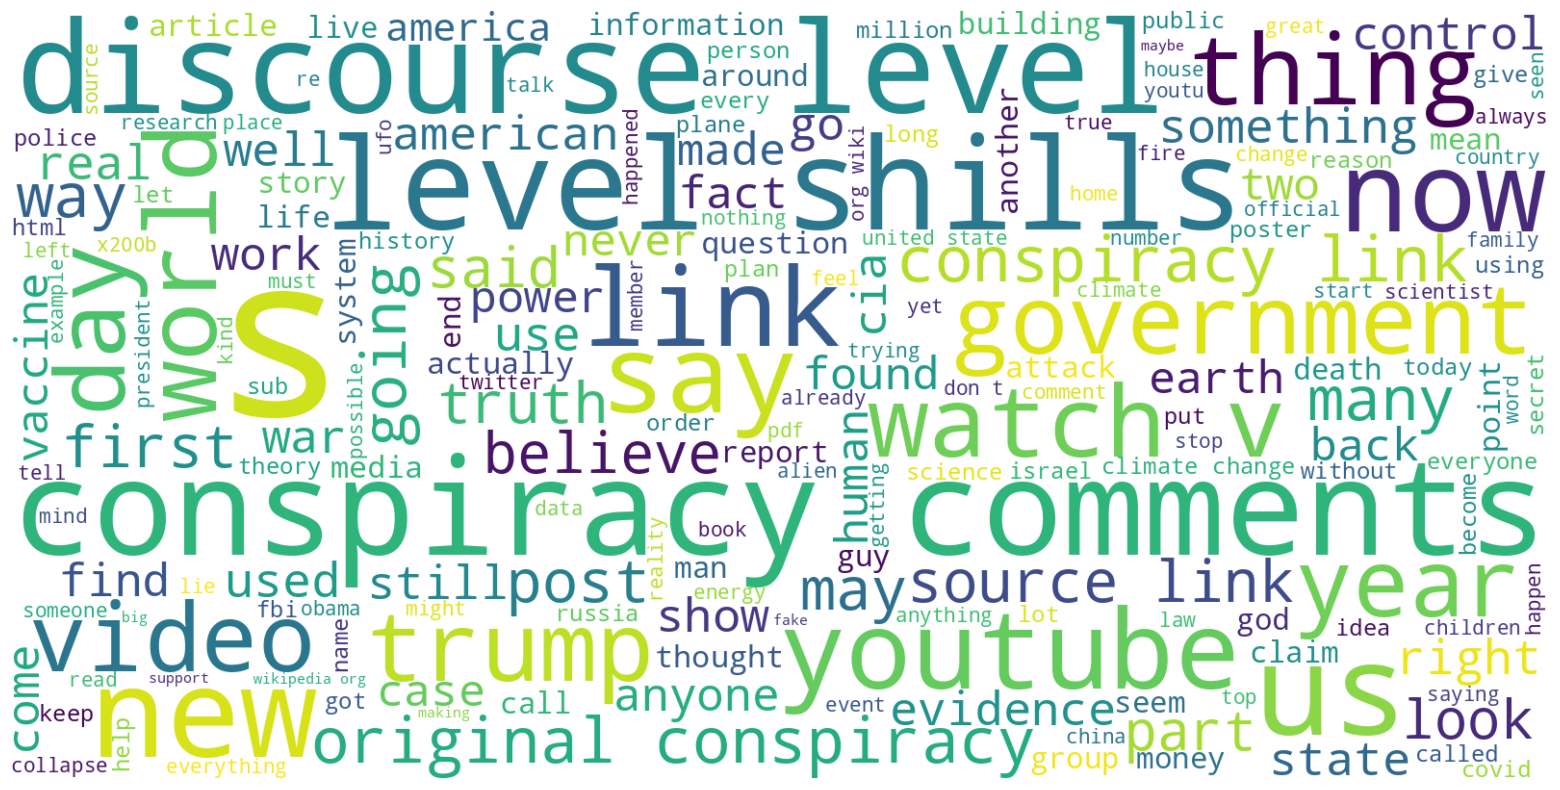

In [10]:
#Wordlcoud


from wordcloud import STOPWORDS

custom = {"https", "http", "www", "com", "reddit", "deleted", "removed", "will", "u", "amp", "gt", "just", "like", "one", "get", "would", "people", "think", "know", "time", "really", "even", "see", "also", "make", "much", "good", "bad", "take", "want", "need"}
stopwords = STOPWORDS | custom

all_text = " ".join(odf["clean_text"])
wc = WordCloud(width=1600, height=800, background_color="white",
               stopwords=stopwords, max_words=200).generate(all_text)
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.tight_layout()

plt.savefig("wordcloud.png", dpi=150)
plt.show()

